<a href="https://colab.research.google.com/github/BrycesonT27/Statistical-Analysis-of-Mass-Shooting-Demographics/blob/main/Official_Gun_Violence_Business_Analytics_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/'Colab Notebooks'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
Gun = pd.read_csv('GUN_NEWW.csv', encoding = 'cp1252')

In [ ]:
# Imputing N/A and 00 for the Null Values in the Dataset

String_Columns = Gun.select_dtypes(include = 'object')
Gun[String_Columns.columns] = String_Columns.fillna('N/A')
Numeric_Columns = Gun.select_dtypes(include = 'number')
Gun[Numeric_Columns.columns] = Numeric_Columns.fillna(00)

Gun['Date'] = pd.to_datetime(Gun['Date'])
Gun['Year'] = Gun['Date'].dt.year
Gun['Month'] = Gun['Date'].dt.month
Gun['Day'] = Gun['Date'].dt.day

In [ ]:
# Fixing duplicates in the Race column

Gun['Race'] = Gun['Race'].replace({'Black American' : 'Black',
                                   'Black American or African American' : 'Black',
                                  'Black American or African American/Unknown' : 'Black',
                                   'black' : 'Black',
                                  'White American or European American' : 'White',
                                  'White American or European American/Some other Race' : 'White',
                                   'white' : 'White',
                                  'Asian American' : 'Asian',
                                  'Asian American/Some other race' : 'Asain',
                                   'Asain' : 'Asian',
                                  'N/A' : 'Other',
                                   'Unknown' : 'Other',
                                   'Some other race' : 'Other',
                                  'Two or more races' : 'Other' })

print(Gun['Race'].unique())

['White' 'Black' 'Asian' 'Other' 'Latino'
 'Native American or Alaska Native' 'Asain']


In [ ]:
Gun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 323 entries, 0 to 322
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   S#                    323 non-null    int64         
 1   Title                 323 non-null    object        
 2   Location              323 non-null    object        
 3   Date                  323 non-null    datetime64[ns]
 4   Incident Area         323 non-null    object        
 5   Open/Close Location   323 non-null    object        
 6   Target                323 non-null    object        
 7   Cause                 323 non-null    object        
 8   Summary               323 non-null    object        
 9   Fatalities            323 non-null    int64         
 10  Injured               323 non-null    int64         
 11  Total victims         323 non-null    int64         
 12  Policeman Killed      323 non-null    float64       
 13  Age                 

In [ ]:
Gun.head(400)

,S#,Title,Location,Date,Incident Area,Open/Close Location,Target,Cause,Summary,Fatalities,...,Employeed (Y/N),Employed at,Mental Health Issues,Race,Gender,Latitude,Longitude,Year,Month,Day
0,1,Texas church mass shooting,"Sutherland Springs, TX",2017-11-05,Church,Close,random,unknown,"Devin Patrick Kelley, 26, an ex-air force offi...",26,...,0.0,N/A,No,White,Male,0.000000,0.000000,2017,11,5
1,2,Walmart shooting in suburban Denver,"Thornton, CO",2017-11-01,Wal-Mart,Open,random,unknown,"Scott Allen Ostrem, 47, walked into a Walmart ...",3,...,0.0,N/A,No,White,Male,0.000000,0.000000,2017,11,1
2,3,Edgewood businees park shooting,"Edgewood, MD",2017-10-18,Remodeling Store,Close,coworkers,unknown,"Radee Labeeb Prince, 37, fatally shot three pe...",3,...,0.0,Advance Granite Store,No,Black,Male,0.000000,0.000000,2017,10,18
3,4,Las Vegas Strip mass shooting,"Las Vegas, NV",2017-10-01,Las Vegas Strip Concert outside Mandala Bay,Open,random,unknown,"Stephen Craig Paddock, opened fire from the 32...",59,...,0.0,N/A,Unclear,White,Male,36.181271,-115.134132,2017,10,1
4,5,San Francisco UPS shooting,"San Francisco, CA",2017-06-14,UPS facility,Close,coworkers,N/A,"Jimmy Lam, 38, fatally shot three coworkers an...",3,...,1.0,N/A,Yes,Asian,Male,0.000000,0.000000,2017,6,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,319,Clara Barton Elementary School,"Chicago, Illinois",1974-01-17,Clara Barton Elementary School,Close,Teachers,anger,"On January 17, 1974, a 14-year-old student ent...",1,...,0.0,N/A,Yes,Other,Male,41.839280,-87.688181,1974,1,17
319,320,New Orleans Police Shootings,"New Orleans, Louisiana",1972-12-31,N/A,N/A,random,psycho,"On New Year's Eve in 1972, a 23-year-old ex-Na...",10,...,0.0,N/A,Yes,Black,Male,30.068724,-89.931474,1972,12,31
320,321,St. Aloysius Church,"Spokane, Washington",1971-11-11,Church,Close,random,terrorism,"On November 11, 1971, a former MIT student ent...",2,...,0.0,N/A,Yes,White,Male,47.673674,-117.415984,1971,11,11
321,322,Rose-Mar College of Beauty,"Mesa, Arizona",1966-11-12,Rose-Mar College of Beauty,Close,random,terrorism,"On November 12, 1966, an 18-year-old high scho...",5,...,0.0,N/A,Yes,White,Male,33.422687,-111.816320,1966,11,12


In [ ]:
# Nulls Removed

print(Gun.isna().sum())

S#                      0
Title                   0
Location                0
Date                    0
Incident Area           0
Open/Close Location     0
Target                  0
Cause                   0
Summary                 0
Fatalities              0
Injured                 0
Total victims           0
Policeman Killed        0
Age                     0
Employeed (Y/N)         0
Employed at             0
Mental Health Issues    0
Race                    0
Gender                  0
Latitude                0
Longitude               0
Year                    0
Month                   0
Day                     0
dtype: int64


In [ ]:
Gun.describe()

,S#,Date,Fatalities,Injured,Total victims,Policeman Killed,Employeed (Y/N),Latitude,Longitude,Year,Month,Day
count,323.000000,323,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000
mean,162.000000,2007-11-16 14:42:43.467492352,4.436533,6.176471,10.263158,0.126935,0.130031,34.920118,-88.582508,2007.439628,5.761610,15.659443
min,1.000000,1966-08-01 00:00:00,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,-161.792752,1966.000000,1.000000,1.000000
25%,81.500000,2001-01-15 12:00:00,1.000000,1.000000,4.000000,0.000000,0.000000,32.863573,-106.692345,2000.500000,2.500000,7.000000
50%,162.000000,2013-11-01 00:00:00,3.000000,3.000000,5.000000,0.000000,0.000000,35.926815,-87.688181,2013.000000,5.000000,16.000000
75%,242.500000,2015-12-02 00:00:00,5.500000,5.000000,9.000000,0.000000,0.000000,41.289861,-80.323238,2015.000000,9.000000,23.500000
max,323.000000,2017-11-05 00:00:00,59.000000,527.000000,585.000000,5.000000,1.000000,60.790539,0.000000,2017.000000,12.000000,31.000000
std,93.386294,NaN,5.783208,29.889182,33.662309,0.604835,0.336859,10.463599,27.844297,11.356664,3.649489,8.908182


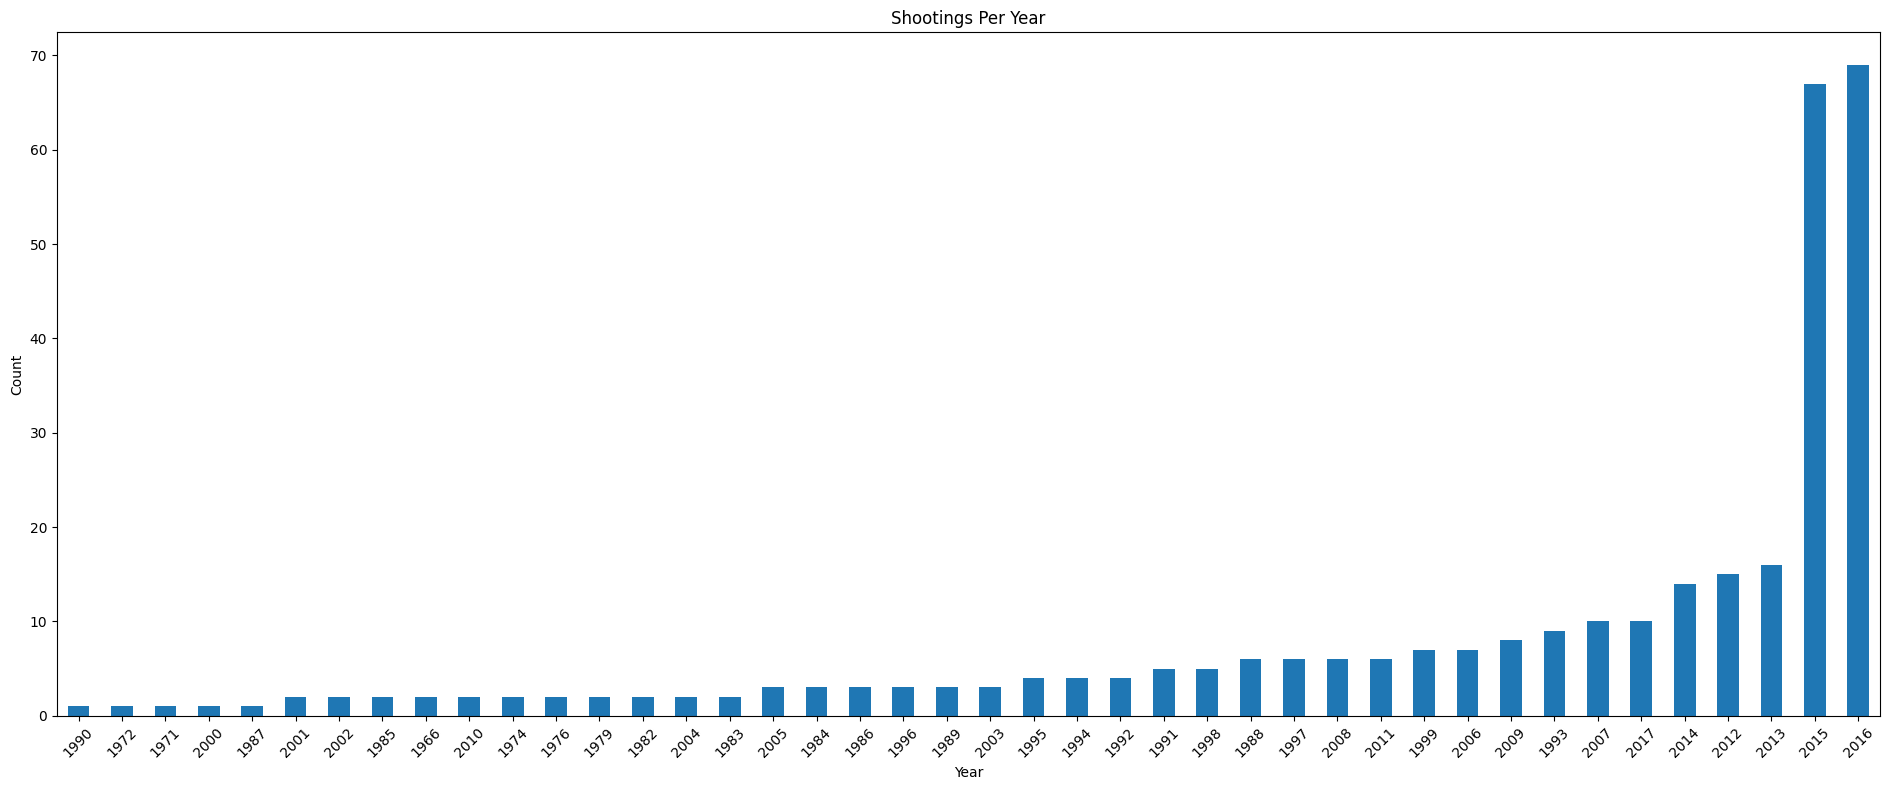

In [ ]:
# How many shootings are there each year?

Shootings_Per_Year = Gun['Year'].value_counts(ascending = True)

plt.figure(figsize = (19,8))
Shootings_Per_Year.plot(kind = 'bar')
plt.title('Shootings Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


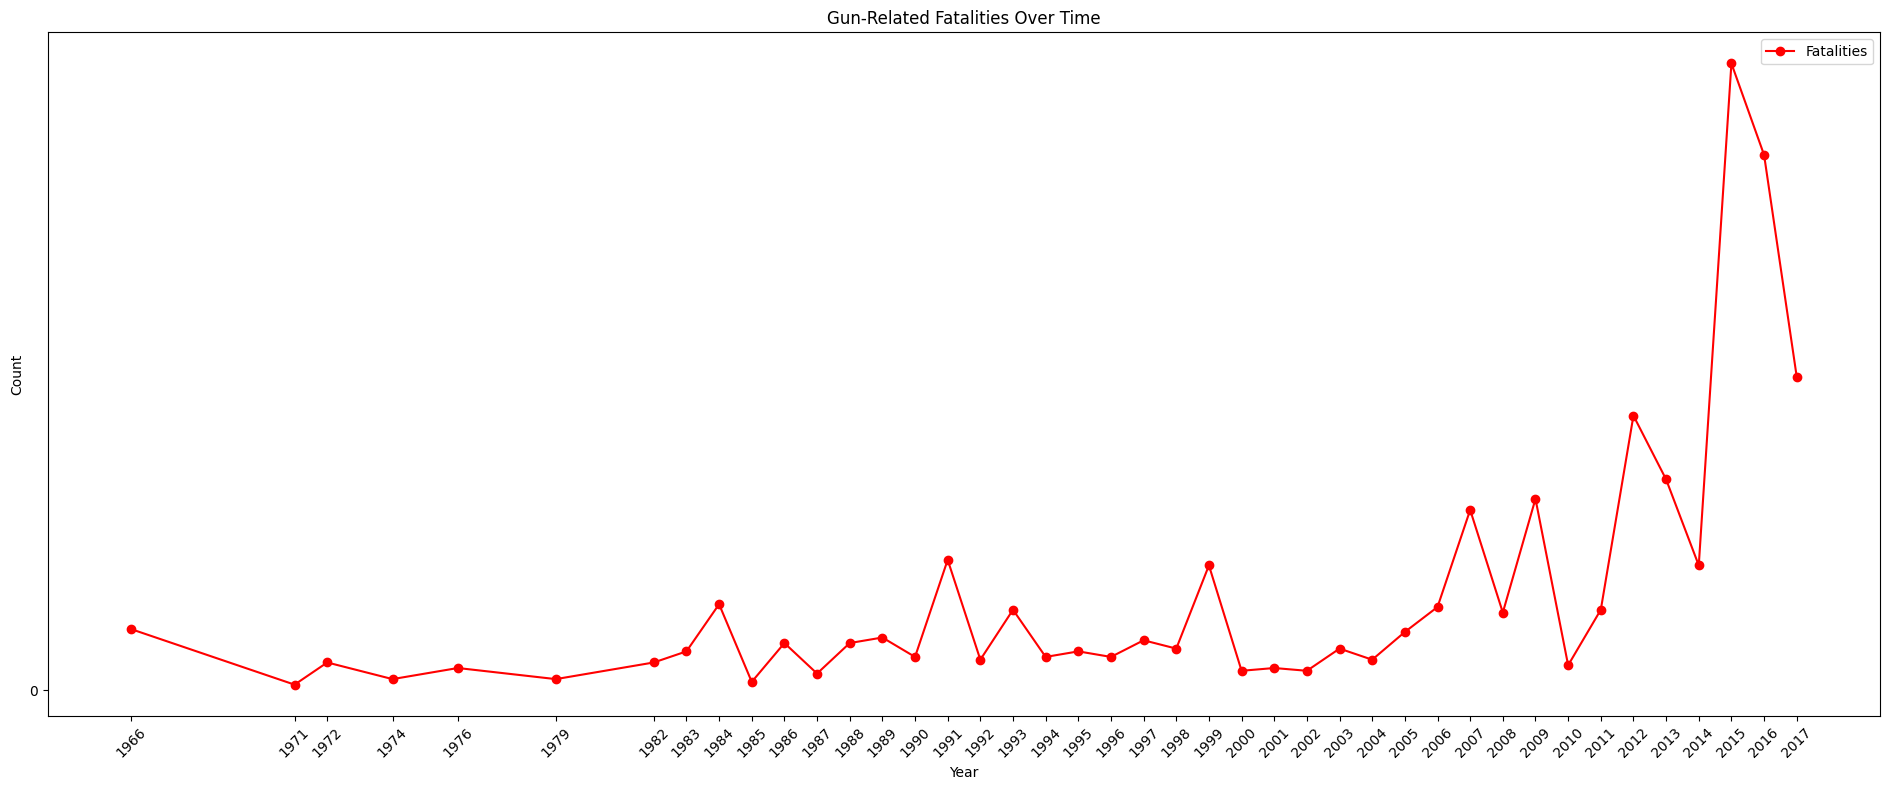

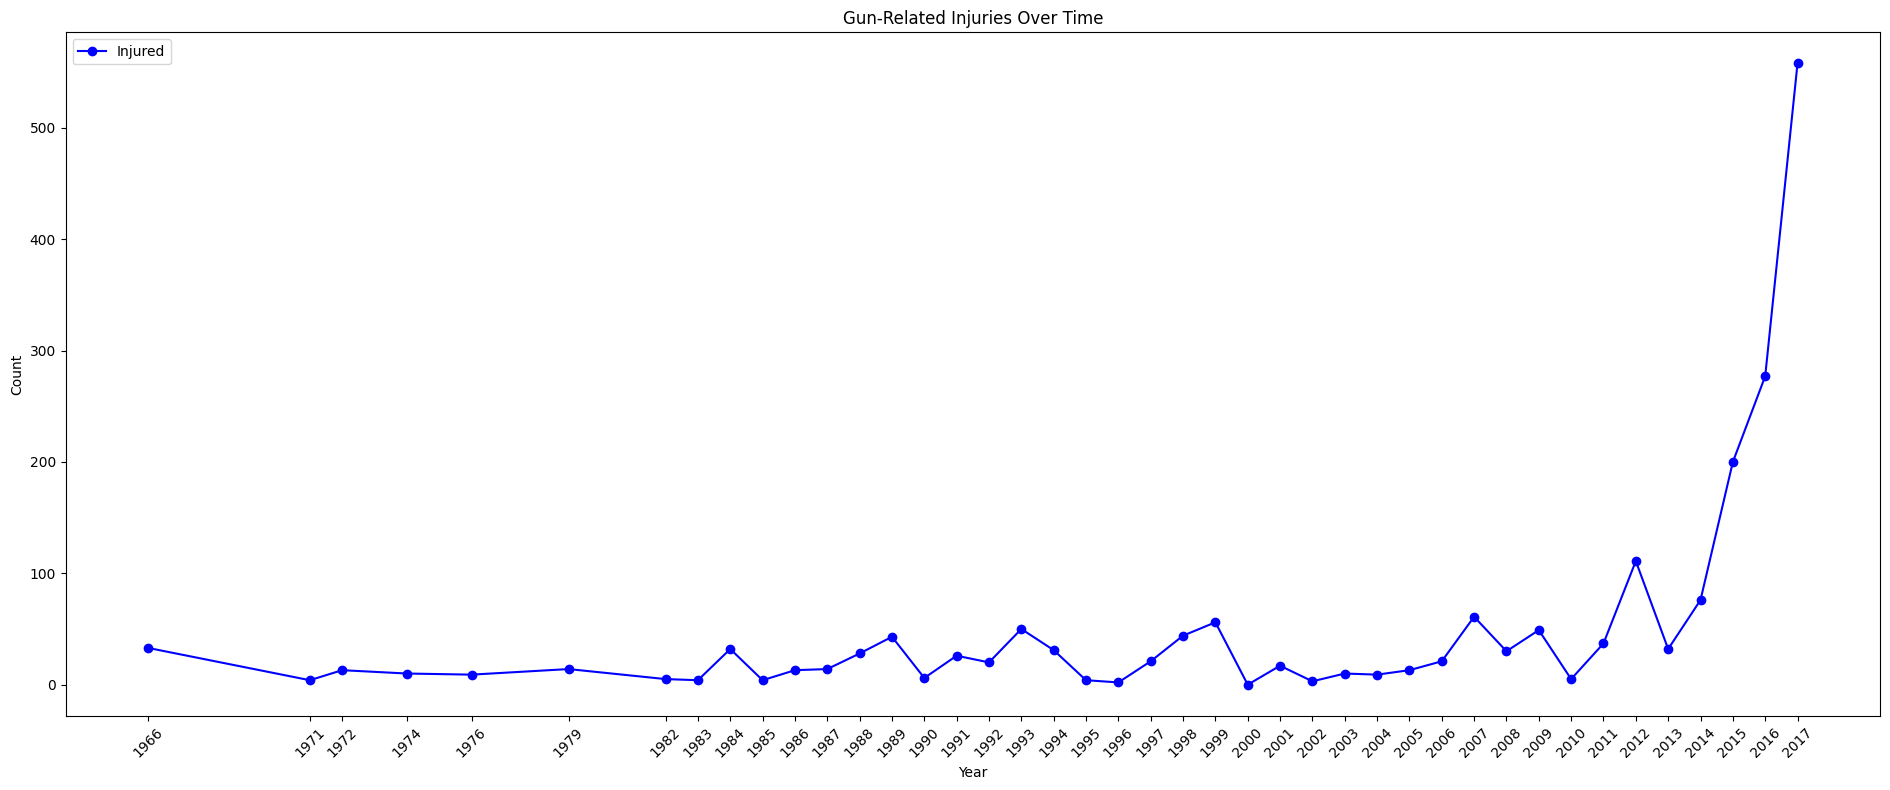

In [ ]:
# How many people get killed and injured each year? / Victimes Per Year

V_Per_Year = Gun.groupby('Year').agg({'Fatalities': 'sum', 'Injured' : 'sum'}).reset_index()

plt.figure(figsize = (19,8))
plt.plot(V_Per_Year['Year'],
         V_Per_Year['Fatalities'], marker = 'o',
         linestyle = '-'
         , label = 'Fatalities', color = 'red')
plt.title('Gun-Related Fatalities Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(V_Per_Year['Year'], rotation = 45)
plt.yticks(range(0, 59, 100))
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize = (19,8))
plt.plot(V_Per_Year['Year'],
         V_Per_Year['Injured'], marker = 'o',
         linestyle = '-'
         , label = 'Injured', color = 'blue')
plt.title('Gun-Related Injuries Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(V_Per_Year['Year'], rotation = 45)
plt.yticks(range(0, 527, 100))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# How many Shootings are attributed to each Gender?

Shootings_By_Gender = Gun.groupby('Gender').agg(Shootings = ('S#', 'count')).reset_index()
Shootings_By_Gender = Shootings_By_Gender.set_index('Gender')
print(Shootings_By_Gender)

             Shootings
Gender                
Female               5
Male               292
Male/Female          5
Unknown             21


In [ ]:
#How many Shootings are attributed to each Race?

Shootings_By_Race = Gun['Race'].value_counts(ascending = False).reset_index(name = 'Shootings')
Shootings_By_Race = Shootings_By_Race.set_index('Race')
print(Shootings_By_Race)



                                  Shootings
Race                                       
White                                   144
Black                                    85
Other                                    68
Asian                                    17
Latino                                    5
Native American or Alaska Native          3
Asain                                     1


<Figure size 1900x800 with 0 Axes>

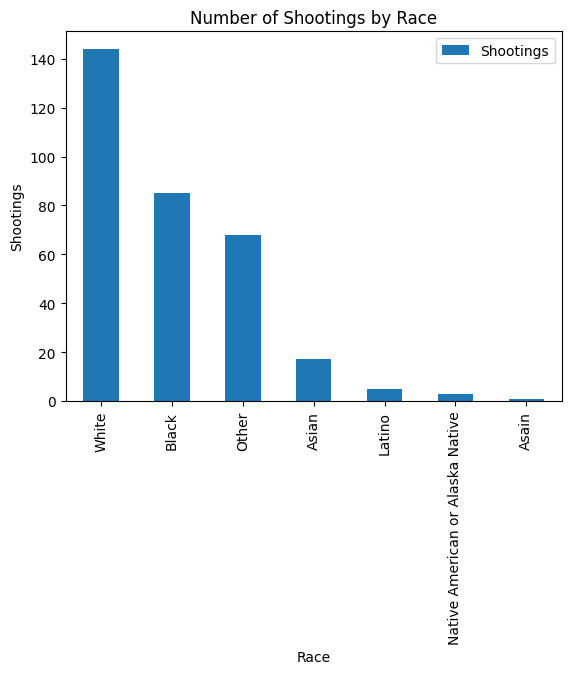

In [ ]:
plt.figure(figsize = (19,8))
Shootings_By_Race.plot(kind = 'bar')
plt.title('Number of Shootings by Race')
plt.xlabel('Race')
plt.ylabel('Shootings')
plt.show()